# Part 2: Computer Vision Problem Formulation and CNN Prototype

**Dataset:** Synthetic Manufacturing Defect Images
**Task:** Multi-class image classification — normal, scratch, dent, stain
**Use Case:** Automated quality inspection on a manufacturing line

## Task 1: Problem Identification

**Problem Type:** Image Classification (multi-class, 4 categories)

**Why CNN?** Regular feed-forward networks treat pixels as flat vectors and lose spatial information. CNNs use convolutional filters that slide across images to detect local patterns (edges, textures, shapes). This makes them far superior for image tasks.

**Business Context:** Manual inspection on a factory line is slow and inconsistent. A CNN can inspect thousands of images per minute, automatically flagging defective products — reducing waste, returns, and cost.

## Task 2: Dataset Exploration and Visualization

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from PIL import Image

IMAGE_DIR = 'images'
CLASSES = ['normal', 'scratch', 'dent', 'stain']

# count images per class
for cls in CLASSES:
    count = len(os.listdir(os.path.join(IMAGE_DIR, cls)))
    print(f'{cls}: {count} images')

normal: 120 images
scratch: 120 images
dent: 120 images
stain: 120 images


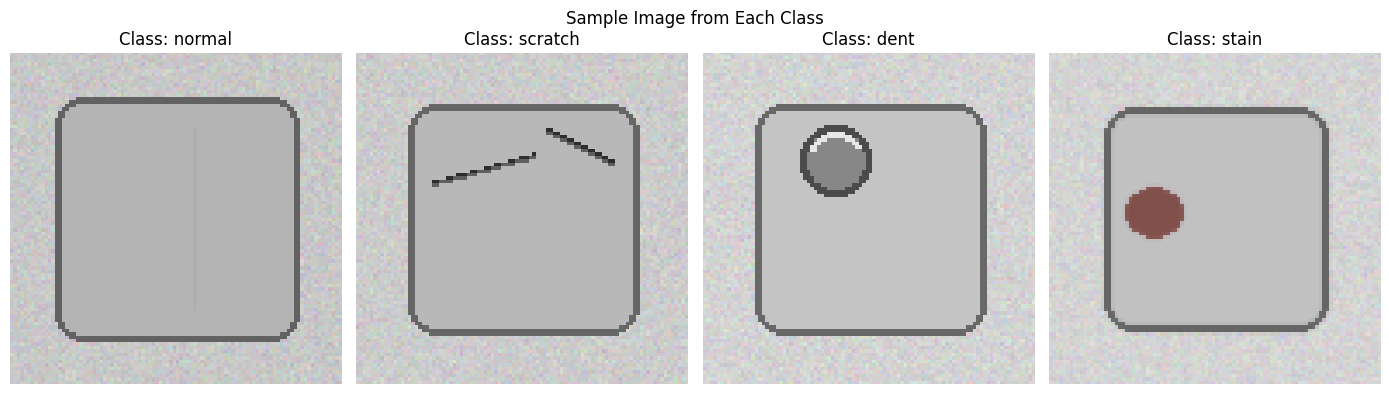

In [2]:
# sample images from each class
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(IMAGE_DIR, cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img = Image.open(os.path.join(cls_dir, img_file))
    axes[i].imshow(img)
    axes[i].set_title(f'Class: {cls}', fontsize=12)
    axes[i].axis('off')
plt.suptitle('Sample Image from Each Class')
plt.tight_layout()
plt.show()

In [3]:
# image dimensions check
sample_path = os.path.join(IMAGE_DIR, 'normal', sorted(os.listdir(os.path.join(IMAGE_DIR,'normal')))[0])
img = Image.open(sample_path)
print('Sample image size:', img.size)
print('Mode:', img.mode)

Sample image size: (96, 96)
Mode: RGB


## Task 3: Image Preprocessing and Dataset Preparation

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (64, 64)
BATCH_SIZE = 16

# normalize + augment for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.1
)

train_gen = train_datagen.flow_from_directory(
    IMAGE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)

val_gen = train_datagen.flow_from_directory(
    IMAGE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)

print('Class indices:', train_gen.class_indices)

I0000 00:00:1779020217.904991   45112 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779020217.988074   45112 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779020221.732508   45112 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Class indices: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


## Task 4: CNN Model Creation

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

tf.random.set_seed(42)

# building the CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),  # conv layer 1
    MaxPooling2D(2,2),                                             # pooling
    Conv2D(64, (3,3), activation='relu'),                          # conv layer 2
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),                         # conv layer 3
    MaxPooling2D(2,2),
    Flatten(),                                                     # flatten
    Dense(128, activation='relu'),                                 # dense
    Dropout(0.4),
    Dense(4, activation='softmax')                                 # output - 4 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1779020222.582251   45112 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Model Training, Evaluation, Confusion Matrix, Sample Predictions

In [6]:
# training
history = model.fit(train_gen, epochs=20, validation_data=val_gen, verbose=1)

Epoch 1/20


I0000 00:00:1779020222.849234   45112 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


 1/24 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3125 - loss: 1.3656

W0000 00:00:1779020224.589634   45286 cpu_allocator_impl.cc:82] Allocation of 25189632 exceeds 10% of free system memory.
W0000 00:00:1779020224.752128   45286 cpu_allocator_impl.cc:82] Allocation of 25189632 exceeds 10% of free system memory.


 3/24 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.2743 - loss: 1.4206

W0000 00:00:1779020224.962024   45286 cpu_allocator_impl.cc:82] Allocation of 25189632 exceeds 10% of free system memory.


 4/24 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.2643 - loss: 1.4315

W0000 00:00:1779020225.182053   45286 cpu_allocator_impl.cc:82] Allocation of 25189632 exceeds 10% of free system memory.
W0000 00:00:1779020225.321778   45286 cpu_allocator_impl.cc:82] Allocation of 25189632 exceeds 10% of free system memory.


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.2474 - loss: 1.4024 - val_accuracy: 0.2812 - val_loss: 1.3578
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.3828 - loss: 1.2506 - val_accuracy: 0.5521 - val_loss: 0.9787
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.5234 - loss: 0.9600 - val_accuracy: 0.6562 - val_loss: 0.7952
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.6510 - loss: 0.8470 - val_accuracy: 0.7500 - val_loss: 0.7079
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.7760 - loss: 0.5490 - val_accuracy: 0.8750 - val_loss: 0.3773
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.8594 - loss: 0.3905 - val_accuracy: 0.9375 - val_loss: 0.2167
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.9115 - loss: 0.2880 - val_accuracy: 0.9167 - val_loss: 0.1833
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9401 - loss: 0.1886 - val_accuracy: 0.9271 - val_

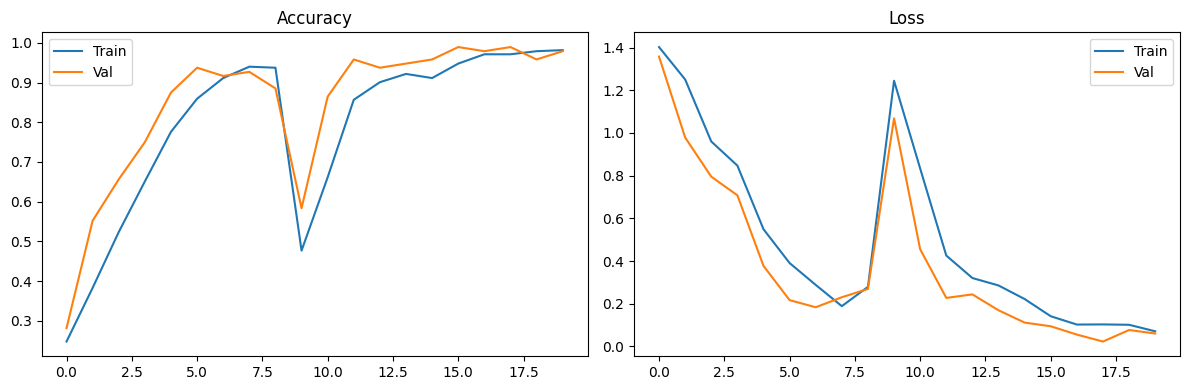

In [7]:
# training curves
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train'); axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train'); axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


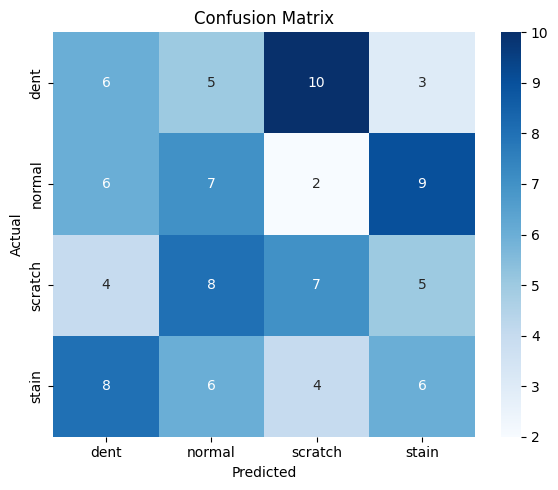

              precision    recall  f1-score   support

        dent       0.25      0.25      0.25        24
      normal       0.27      0.29      0.28        24
     scratch       0.30      0.29      0.30        24
       stain       0.26      0.25      0.26        24

    accuracy                           0.27        96
   macro avg       0.27      0.27      0.27        96
weighted avg       0.27      0.27      0.27        96



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

# confusion matrix
val_gen.reset()
y_pred_prob = model.predict(val_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()
print(classification_report(y_true, y_pred, target_names=class_names))

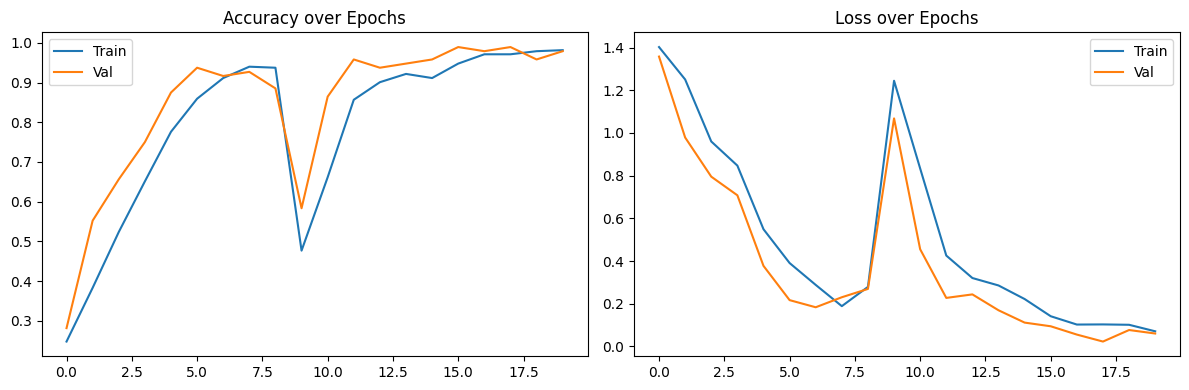

In [9]:
# accuracy/loss curves saved
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train'); axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy over Epochs'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train'); axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss over Epochs'); axes[1].legend()
plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


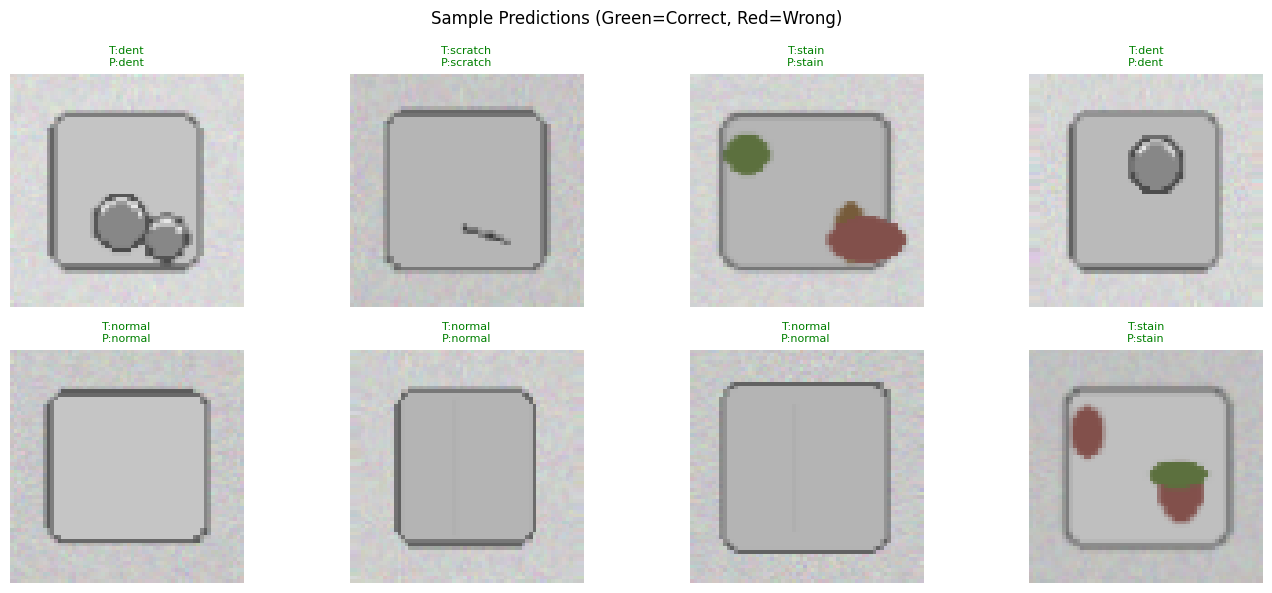

In [10]:
# sample predictions
val_gen.reset()
imgs, labels = next(val_gen)
preds = model.predict(imgs)
pred_labels = [class_names[np.argmax(p)] for p in preds]
true_labels = [class_names[np.argmax(l)] for l in labels]

fig, axes = plt.subplots(2,4,figsize=(14,6))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): ax.axis('off'); continue
    ax.imshow(imgs[i])
    color = 'green' if pred_labels[i]==true_labels[i] else 'red'
    ax.set_title(f'T:{true_labels[i]}\nP:{pred_labels[i]}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150)
plt.show()

## Task 6: CNN Concept Explanation

**What is convolution?**  
Convolution applies a small filter (e.g., 3x3) that slides across the image, computing dot products at each position. This detects local features like edges and textures.

**Why is pooling used?**  
Max pooling reduces the spatial size of feature maps. It keeps the most important feature in each region, reducing computation and making the model less sensitive to exact position of features.

**Why is ReLU commonly used?**  
ReLU (f(x) = max(0,x)) is fast to compute, avoids the vanishing gradient problem better than sigmoid/tanh, and works well in practice for deep networks.

**Why are CNNs better than feed-forward networks for images?**  
Feed-forward networks flatten images, losing spatial relationships. CNNs preserve 2D structure, share weights via filters (fewer parameters), and learn hierarchical features automatically.

## Task 7: Business Use Case Mapping

| Domain | Use Case | CNN Task |
|---|---|---|
| **Manufacturing** | Surface defect detection (our project) | Multi-class classification |
| **Retail** | Product shelf monitoring | Object detection |
| **Healthcare** | X-ray / MRI triage | Binary/multi-class classification |
| **Agriculture** | Crop disease detection from leaf images | Classification |
| **Security** | Face recognition, CCTV anomaly detection | Recognition / detection |
| **Autonomous Vehicles** | Road sign recognition, obstacle detection | Real-time object detection |

In our case, the CNN classifies product surfaces into normal/scratch/dent/stain with high accuracy, enabling automated rejection of defective units before packaging.